# 8. Tutorial 8 - Coding Solutions

## 8.6. Impedance of a hybrid capacitor bank

**Course:** Power Electronics Devices and Components

A DC-link capacitor bank contains three parallel branches:

- **Electrolytic:** $C=1000~\mu\mathrm{F}$, $R_{\mathrm{ESR}}=40~\mathrm{m\Omega}$, $L_{\mathrm{ESL}}=20~\mathrm{nH}$
- **Film:** $C=20~\mu\mathrm{F}$, $R_{\mathrm{ESR}}=8~\mathrm{m\Omega}$, $L_{\mathrm{ESL}}=8~\mathrm{nH}$
- **MLCC bank:** effective $C=2.2~\mu\mathrm{F}$, $R_{\mathrm{ESR}}=3~\mathrm{m\Omega}$

Compare two MLCC placements:

- local placement: $L_{\mathrm{ESL}}=1~\mathrm{nH}$
- remote placement: total branch inductance $L_{\mathrm{ESL}}=10~\mathrm{nH}$

Use the frequency range

$$10~\mathrm{Hz}\le f\le100~\mathrm{MHz}$$

and target impedance

$$Z_{\mathrm{target}}=20~\mathrm{m\Omega}.$$

The impedance of one real capacitor branch is

$$Z_k(f)=R_k+j\left(2\pi fL_k-\frac{1}{2\pi fC_k}\right),$$

and the parallel-bank impedance is

$$Z_{\mathrm{bank}}=\left(\sum_k\frac{1}{Z_k}\right)^{-1}.$$

### Part A - Define the components

8.6.1 Import `numpy` as `np` and `matplotlib.pyplot` as `plt`.

8.6.2 Assign variables for all capacitance, ESR, ESL, frequency-range, and target-impedance values.

8.6.3 Create a function `capacitor_impedance(f, C, ESR, ESL)` that returns the complex branch impedance.

8.6.4 Create a function `parallel_impedance(*branches)` that returns the complex impedance of parallel branches.

### Part B - Individual capacitor behavior

8.6.5 Create a function `self_resonant_frequency(C, ESL)` using $$f_{\mathrm{SRF}}=\frac{1}{2\pi\sqrt{LC}}.$$

8.6.6 Create a `function local_extrema(y)`, that returns the minimum and maxiumum indices of an np-array

8.6.7 Create a `function intervals_below(f, y, threshold)`, that returns the interval below a threshold

8.6.7 Create a function `intervals_below(f, y, threshold)`, that returns the interval below a threshold
Return "[(f[start], f[end]) for start, end in zip(starts, ends)]" where starts and ends contains the list indices.

8.6.8 Plot the impedance magnitude of the electrolytic, film, and locally mounted MLCC branches. Use logarithmic frequency and impedance axes and mark the calculated self-resonant frequencies.

8.6.9 Explain why the branch with the largest capacitance is not the lowest-impedance branch at every frequency.

### Part C - Parallel network and anti-resonance

8.6.10 Calculate and plot the total bank impedance for the locally mounted MLCC. Add the $20~\mathrm{m\Omega}$ target-impedance line.

8.6.11 Numerically detect local impedance minima and anti-resonance maxima.

8.6.12 Determine all frequency intervals where

$$|Z_{\mathrm{bank}}|<20~\mathrm{m\Omega}.$$

### Part D - Layout effect

8.6.13 Repeat the bank calculation using $10~\mathrm{nH}$ for the remote MLCC branch.

8.6.14 Plot the local and remote bank impedances in one graph.

8.6.15 Compare both impedances at $5~\mathrm{MHz}$ and explain why remote placement can make an otherwise suitable MLCC ineffective for a WBG switching loop.

## 8.6. Impedance of a hybrid capacitor bank

In [15]:
# Subtask 8.6.1 Import `numpy` as `np` and `matplotlib.pyplot` as `plt`.

import numpy as np
import matplotlib.pyplot as plt

# Subtask 8.6.2 Assign variables for all capacitance, ESR, ESL, frequency-range, and target-impedance values.

# Frequency range and target impedance
frequency = np.logspace(1, 8, 40_000)
target_impedance = 20e-3

# Branch parameters: C [F], ESR [ohm], ESL [H]
electrolytic = {"C": 1000e-6, "ESR": 40e-3, "ESL": 20e-9}
film = {"C": 20e-6, "ESR": 8e-3, "ESL": 8e-9}
mlcc_local = {"C": 2.2e-6, "ESR": 3e-3, "ESL": 1e-9}
mlcc_remote = {"C": 2.2e-6, "ESR": 3e-3, "ESL": 10e-9}

# Subtask 8.6.3 Create a function `capacitor_impedance(f, C, ESR, ESL)` that returns the complex branch impedance.

def capacitor_impedance(f, C, ESR, ESL):
    """Return complex impedance of a series ESR-ESL-C model."""
    f = np.asarray(f, dtype=float)
    if np.any(f <= 0) or C <= 0 or ESR < 0 or ESL < 0:
        raise ValueError("Use positive frequency/capacitance and non-negative ESR/ESL.")
    omega = 2 * np.pi * f
    return ESR + 1j * (omega * ESL - 1 / (omega * C))

# Subtask 8.6.4 Create a function `parallel_impedance(*branches)` that returns the complex impedance of parallel branches.

def parallel_impedance(*branches):
    """Return equivalent complex impedance of parallel branch arrays."""
    if not branches:
        raise ValueError("At least one branch is required.")
    admittance = np.zeros_like(np.asarray(branches[0]), dtype=complex)
    for branch in branches:
        admittance += 1 / np.asarray(branch)
    return 1 / admittance

# Subtask 8.6.5 Create a function self_resonant_frequency(C, ESL)

def self_resonant_frequency(C, ESL):
    return 1 / (2 * np.pi * np.sqrt(C * ESL))


# Subtask 8.6.6 Create a function local_extrema(y), that returns the minimum and maxiumum indices of an np-array
def local_extrema(y):
    """Return indices of strict local minima and maxima."""
    y = np.asarray(y)
    # [Start index: End index] with '-' are count from the end. Index start is 0.
    # [1:-1] = all elements except first and last, [:-2] all elements except the last 2
    minima = np.where((y[1:-1] < y[:-2]) & (y[1:-1] < y[2:]))[0] + 1
    maxima = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    test= np.where((y[1:-1] < y[:-2]) & (y[1:-1] < y[2:]))
    return minima, maxima


# Subtask 8.6.7 Create a function intervals_below(f, y, threshold), that returns the interval below a threshold

def intervals_below(f, y, threshold):
    # Calculate boolean mask for the complete list
    mask = np.asarray(y) < threshold
    # Identify border (False to True or vice versa)
    changes = np.diff(mask.astype(int))
    # Store border index for start and end
    starts = list(np.where(changes == 1)[0] + 1)
    ends = list(np.where(changes == -1)[0])
    # Check if first element is still below the theshold (not detected by diff)
    if mask[0]:
        # Add it the first index as first entry to the start list
        starts.insert(0, 0)
    # Check if last element is still below the theshold (not detected by diff)
    if mask[-1]:
        # Add the last index as last entry to the end list
        ends.append(len(mask) - 1)
    # Return the lists
    return [(f[start], f[end]) for start, end in zip(starts, ends)]

In [16]:
#  Calculate capacitor impedance for all capacitor types
Z_electrolytic = capacitor_impedance(frequency, **electrolytic)
Z_film = capacitor_impedance(frequency, **film)
Z_mlcc_local = capacitor_impedance(frequency, **mlcc_local)
Z_mlcc_remote = capacitor_impedance(frequency, **mlcc_remote)

srf = {
    "Electrolytic": self_resonant_frequency(electrolytic["C"], electrolytic["ESL"]),
    "Film": self_resonant_frequency(film["C"], film["ESL"]),
    "MLCC local": self_resonant_frequency(mlcc_local["C"], mlcc_local["ESL"]),
    "MLCC remote": self_resonant_frequency(mlcc_remote["C"], mlcc_remote["ESL"]),
}

for name, value in srf.items():
    print(f"{name:14s} SRF = {value/1e3:10.3f} kHz")

Electrolytic   SRF =     35.588 kHz
Film           SRF =    397.887 kHz
MLCC local     SRF =   3393.195 kHz
MLCC remote    SRF =   1073.022 kHz


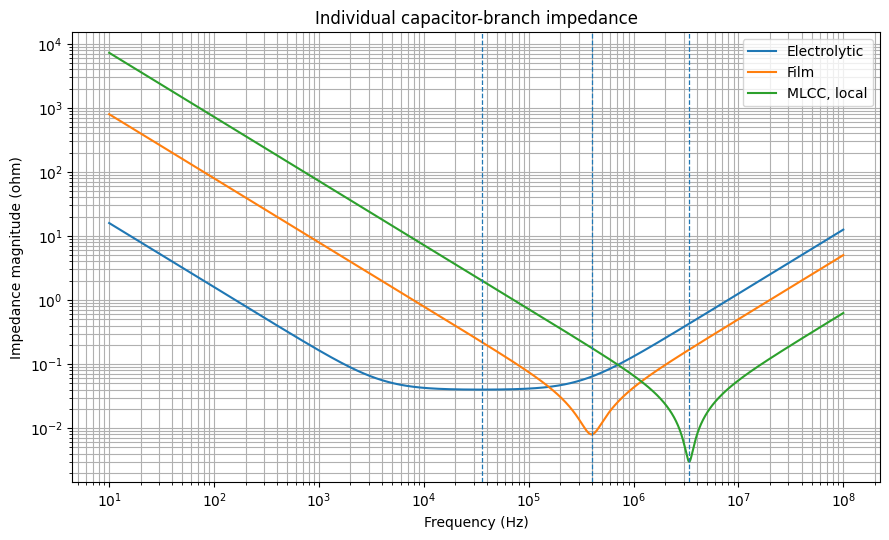

In [17]:
# Subtask 8.6.8 Plot the impedance magnitude of the electrolytic, film, and locally mounted MLCC branches.

plt.figure(figsize=(9, 5.5))
plt.loglog(frequency, np.abs(Z_electrolytic), label="Electrolytic")
plt.loglog(frequency, np.abs(Z_film), label="Film")
plt.loglog(frequency, np.abs(Z_mlcc_local), label="MLCC, local")
# Add vertical line at each minimum
for name in ("Electrolytic", "Film", "MLCC local"):
    plt.axvline(srf[name], linestyle="--", linewidth=0.9)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance magnitude (ohm)")
plt.title("Individual capacitor-branch impedance")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

**Subtask 8.6.9** Explain why the branch with the largest capacitance is not the lowest-impedance branch at every frequency.<br>
**Answer**
The branch with the largest capacitance is only the lowest-impedance path at low frequencies due to the increasing influence of parasitic elements (ESR and ESL) as frequency rises. For mid frequencies, film capacitors are a better choice because of their high capacitance. At higher frequencies, MLCCs are the best choice because their low ESL and ESR outweigh their smaller capacitance.


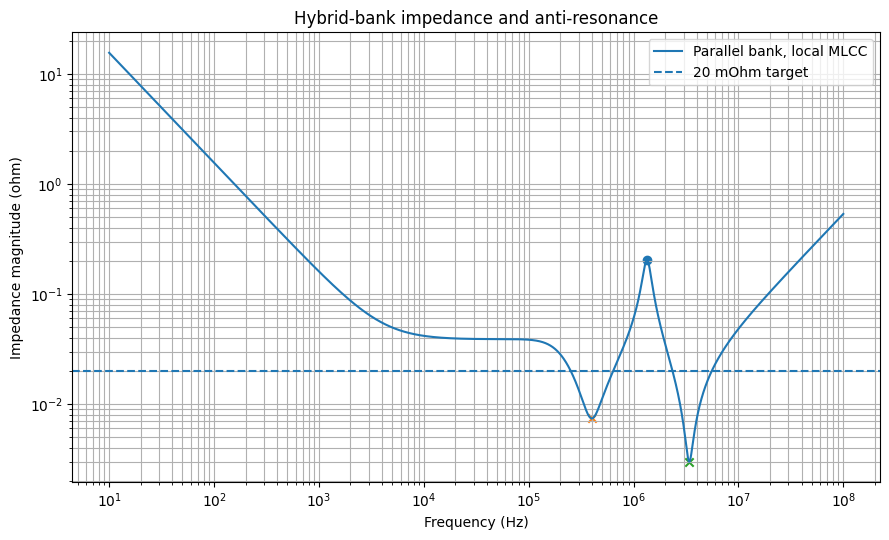

Local-bank extrema:
  minimum at 0.4000 MHz: 7.399 mOhm
  minimum at 3.3991 MHz: 2.994 mOhm
  anti-resonance at 1.3427 MHz: 205.557 mOhm

Frequency bands below 20 mOhm:
  0.2518 MHz to 0.6392 MHz
  2.3518 MHz to 5.5686 MHz


In [18]:
# Subtask 8.6.9 Explain why the branch with the largest capacitance is not the lowest-impedance branch at every frequency.
#-> Missing explanation

# Subtask 8.6.10 Calculate and plot the total bank impedance for the locally mounted MLCC.

Z_bank_local = parallel_impedance(Z_electrolytic, Z_film, Z_mlcc_local)
magnitude_local = np.abs(Z_bank_local)
minima_local, maxima_local = local_extrema(magnitude_local)
bands_local = intervals_below(frequency, magnitude_local, target_impedance)



plt.figure(figsize=(9, 5.5))
plt.loglog(frequency, magnitude_local, label="Parallel bank, local MLCC")
plt.axhline(target_impedance, linestyle="--", label="20 mOhm target")
for index in maxima_local:
    plt.scatter(frequency[index], magnitude_local[index], marker="o")
for index in minima_local:
    plt.scatter(frequency[index], magnitude_local[index], marker="x")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance magnitude (ohm)")
plt.title("Hybrid-bank impedance and anti-resonance")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

# Subtask 8.6.11 Numerically detect local impedance minima and anti-resonance maxima.

print("Local-bank extrema:")
for index in minima_local:
    print(f"  minimum at {frequency[index]/1e6:.4f} MHz: {magnitude_local[index]*1e3:.3f} mOhm")
for index in maxima_local:
    print(f"  anti-resonance at {frequency[index]/1e6:.4f} MHz: {magnitude_local[index]*1e3:.3f} mOhm")

# Subtask 8.6.12 Determine all frequency intervals where Z_bank<20Ohm.

print("\nFrequency bands below 20 mOhm:")
for start, end in bands_local:
    print(f"  {start/1e6:.4f} MHz to {end/1e6:.4f} MHz")


In [19]:
# Subtask 8.6.13 Repeat the bank calculation using 10nH for the remote MLCC branch.

Z_bank_remote = parallel_impedance(Z_electrolytic, Z_film, Z_mlcc_remote)
magnitude_remote = np.abs(Z_bank_remote)
minima_remote, maxima_remote = local_extrema(magnitude_remote)
bands_remote = intervals_below(frequency, magnitude_remote, target_impedance)

evaluation_frequency = 5e6
evaluation_index = np.argmin(np.abs(frequency - evaluation_frequency))

print(f"At 5 MHz, local-bank impedance  = {magnitude_local[evaluation_index]*1e3:.3f} mOhm")
print(f"At 5 MHz, remote-bank impedance = {magnitude_remote[evaluation_index]*1e3:.3f} mOhm")
print("Remote-bank frequency bands below 20 mOhm:")
for start, end in bands_remote:
    print(f"  {start/1e6:.4f} MHz to {end/1e6:.4f} MHz")

At 5 MHz, local-bank impedance  = 15.716 mOhm
At 5 MHz, remote-bank impedance = 112.050 mOhm
Remote-bank frequency bands below 20 mOhm:
  0.2514 MHz to 0.6209 MHz
  0.9766 MHz to 1.3822 MHz


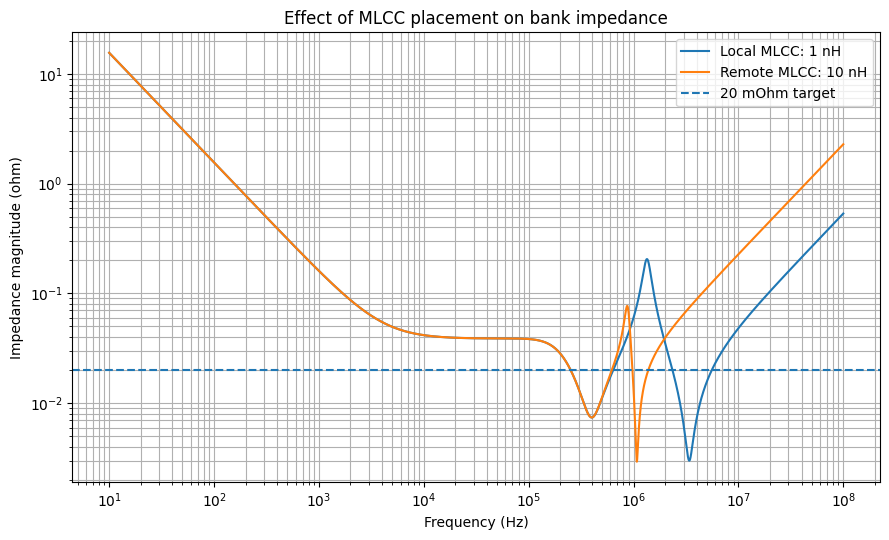

In [20]:
# Subtask 8.6.14 Plot the local and remote bank impedances in one graph.

plt.figure(figsize=(9, 5.5))
plt.loglog(frequency, magnitude_local, label="Local MLCC: 1 nH")
plt.loglog(frequency, magnitude_remote, label="Remote MLCC: 10 nH")
plt.axhline(target_impedance, linestyle="--", label="20 mOhm target")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance magnitude (ohm)")
plt.title("Effect of MLCC placement on bank impedance")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

**Subtask 8.6.15** Compare both impedances at 5MHz and explain why remote placement can make an otherwise suitable MLCC ineffective for a WBG switching loop.

**Interpretation.** The three branches dominate different frequency ranges. Their parallel connection creates both low-impedance resonances and a pronounced anti-resonance peak. Increasing the MLCC branch inductance from $1~\mathrm{nH}$ to $10~\mathrm{nH}$ shifts its resonance downward and makes the bank much less effective near $5~\mathrm{MHz}$. The MLCC must therefore be placed inside the commutation loop rather than merely somewhere on the DC bus.

## 8.7. Mission-profile-based capacitor lifetime

The capacitor has the following base-life and thermal data:

- base life: $L_b=5000~\mathrm{h}$
- maximum reference temperature: $T_m=105^\circ\mathrm{C}$
- voltage derating multiplier: $M_v=1.1$
- thermal resistance: $R_{\mathrm{th}}=5~\mathrm{K/W}$

Full-load ripple-current spectrum:

| Frequency | RMS current | ESR |
|---:|---:|---:|
| $100~\mathrm{Hz}$ | $6~\mathrm{A}$ | $30~\mathrm{m\Omega}$ |
| $10~\mathrm{kHz}$ | $4~\mathrm{A}$ | $15~\mathrm{m\Omega}$ |
| $100~\mathrm{kHz}$ | $2~\mathrm{A}$ | $20~\mathrm{m\Omega}$ |

Use

$$I_{\mathrm{rms}}=\sqrt{\sum_k I_k^2},$$

$$P_{\mathrm{loss}}=\sum_k I_k^2R_{\mathrm{ESR}}(f_k),$$

$$T_{\mathrm{hotspot}}=T_{\mathrm{amb}}+R_{\mathrm{th}}P_{\mathrm{loss}},$$

$$L_{\mathrm{op}}=M_vL_b2^{(T_m-T_{\mathrm{hotspot}})/10}.$$

Mission profile:

| Segment | Time fraction | Ambient temperature | Ripple-current scale |
|:---:|---:|---:|---:|
| A | $60\%$ | $55^\circ\mathrm{C}$ | $0.7$ |
| B | $30\%$ | $70^\circ\mathrm{C}$ | $1.0$ |
| C | $10\%$ | $85^\circ\mathrm{C}$ | $1.3$ |

Assume linear damage accumulation according:

$$L_\mathrm{eq}=\left(\sum_i\frac{\alpha_i}{L_i}\right)^{-1}.$$

This equation calculates the equivalent lifetime of the capacitor under a mission profile containing several operating conditions.

Meaning of each term
- $L_\mathrm{eq}$ equivalent lifetime under the complete mission profile, in hours.
- $i$ operating segment, such as low-, medium-, or high-temperature operation.
- $\alpha_i$ fraction of total operating time spent in segment .
- $L_i$ capacitor lifetime if it operated continuously under the conditions of segment .
The time fractions must satisfy

$$\sum_i\alpha_i=1.$$

### Part A - Spectral ripple loss

8.7.1 Assign all constant values and create arrays for the harmonic currents and frequency-dependent ESR values.

8.7.2 Create function `total_rms_current(currents)` to calculate total RMS current.

8.7.3 Create function `spectral_loss(currents, esr)` to calculate the spectral loss with nd-array harmonic_currents and harmonic_esr.<br>
      &emsp; &emsp;Check, if the input arrays has the same size, otherwise raise a value error.

8.7.4 Create function `hotspot_temperature(ambient, loss, r_th=thermal_resistance)` to calculate the hotspot temperature.

8.7.5 Create function `expected_life(hotspot)` to calculate the expected lifetime based on Voltage multiplier and reference temperature.

8.7.6 Calculate the full-load RMS ripple current and frequency-dependent loss.

8.7.7 Compare the correct result with the incorrect approximation that uses the $100~\mathrm{Hz}$ ESR for every harmonic and print the result.

### Part B - Mission-profile calculation

8.7.8 For every mission-profile segment, scale all harmonic currents and calculate loss, hot-spot temperature, and segment life. Print the results.

8.7.9 Plot hot-spot temperature and expected life versus mission-profile segment in separate figures.

### Part C - Accumulated damage

8.7.10 Calculate the equivalent mission-profile lifetime using linear damage accumulation and print the result.

8.7.11 Repeat the calculation using only the weighted-average ambient temperature and weighted-average current scale.

8.7.12 Quantify the percentage error introduced by the average-condition shortcut and explain why it occurs.

### Part D - Ageing feedback

8.7.13 Repeat the full-load calculation at $70^\circ\mathrm{C}$ ambient after all ESR values have doubled.

8.7.14 Compare the original and aged losses, hot-spot temperatures, and lifetimes. Explain the feedback chain

$$R_{\mathrm{ESR}}\uparrow\Rightarrow P_{\mathrm{loss}}\uparrow\Rightarrow T_{\mathrm{hotspot}}\uparrow\Rightarrow\text{accelerated ageing}.$$

In [21]:
# Subtask 8.7.1 Assign all constant values and create arrays for the harmonic currents and frequency-dependent ESR values.

# Base-life and thermal data
base_life = 5000.0          # h
reference_temperature = 105.0  # degree C
voltage_multiplier = 1.1
thermal_resistance = 5.0    # K/W

harmonic_frequencies = np.array([100.0, 10e3, 100e3])
harmonic_currents = np.array([6.0, 4.0, 2.0])
harmonic_esr = np.array([30e-3, 15e-3, 20e-3])

time_fraction = np.array([0.60, 0.30, 0.10])
ambient_temperature = np.array([55.0, 70.0, 85.0])
current_scale = np.array([0.70, 1.00, 1.30])
segment_names = np.array(["A", "B", "C"])

# Subtask 8.7.2 Create function total_rms_current(currents) to calculate total RMS current
def total_rms_current(currents):
    currents = np.asarray(currents, dtype=float)
    return np.sqrt(np.sum(currents**2))

# Subtask 8.7.3 Create function spectral_loss(currents, esr) to calculate the spectral loss
def spectral_loss(currents, esr):
    currents = np.asarray(currents, dtype=float)
    esr = np.asarray(esr, dtype=float)
    if currents.shape != esr.shape:
        raise ValueError("Current and ESR arrays must have identical shapes.")
    return np.sum(currents**2 * esr)

# Subtask 8.7.4 Create function hotspot_temperature(ambient, loss, r_th=thermal_resistance) to calculate the hotspot temperature.
def hotspot_temperature(ambient, loss, r_th=thermal_resistance):
    return ambient + r_th * loss

# Subtask 8.7.5 Create function expected_life(hotspot) to calculate the expected lifetime based on Voltage multiplier and reference temperature.
def expected_life(hotspot):
    return voltage_multiplier * base_life * 2 ** ((reference_temperature - hotspot) / 10)




In [22]:
# Subtask 8.7.6 Calculate the full-load RMS ripple current and frequency-dependent loss.
full_load_rms = total_rms_current(harmonic_currents)
full_load_loss = spectral_loss(harmonic_currents, harmonic_esr)
# Subtask 8.7.7 Compare the correct result with the incorrect approximation that uses the $100~\mathrm{Hz}$ ESR for every harmonic.
incorrect_loss = full_load_rms**2 * harmonic_esr[0]

print(f"Full-load RMS ripple current     = {full_load_rms:.3f} A")
print(f"Frequency-dependent loss        = {full_load_loss:.3f} W")
print(f"Loss using 100-Hz ESR everywhere = {incorrect_loss:.3f} W")
print(f"Approximation error             = {(incorrect_loss/full_load_loss - 1)*100:.1f} %")

Full-load RMS ripple current     = 7.483 A
Frequency-dependent loss        = 1.400 W
Loss using 100-Hz ESR everywhere = 1.680 W
Approximation error             = 20.0 %


In [23]:
# Subtask 8.7.8 For every mission-profile segment, scale all harmonic currents and calculate loss, hot-spot temperature, and segment life.
segment_loss = np.empty_like(time_fraction)
segment_hotspot = np.empty_like(time_fraction)
segment_life = np.empty_like(time_fraction)

for index, scale in enumerate(current_scale):
    scaled_currents = harmonic_currents * scale
    segment_loss[index] = spectral_loss(scaled_currents, harmonic_esr)
    segment_hotspot[index] = hotspot_temperature(ambient_temperature[index], segment_loss[index])
    segment_life[index] = expected_life(segment_hotspot[index])

print("Segment results:")
for name, loss, hotspot, life in zip(segment_names, segment_loss, segment_hotspot, segment_life):
    print(f"  {name}: loss={loss:.3f} W, hotspot={hotspot:.2f} degC, life={life:,.0f} h")

Segment results:
  A: loss=0.686 W, hotspot=58.43 degC, life=138,758 h
  B: loss=1.400 W, hotspot=77.00 degC, life=38,304 h
  C: loss=2.366 W, hotspot=96.83 degC, life=9,690 h


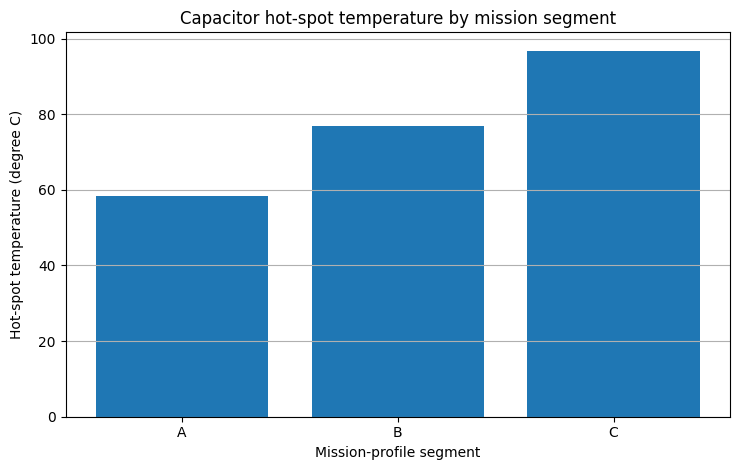

In [24]:
# Subtask 8.7.9 Plot hot-spot temperature and expected life versus mission-profile segment in separate figures.

plt.figure(figsize=(7.5, 4.8))
plt.bar(segment_names, segment_hotspot)
plt.xlabel("Mission-profile segment")
plt.ylabel("Hot-spot temperature (degree C)")
plt.title("Capacitor hot-spot temperature by mission segment")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

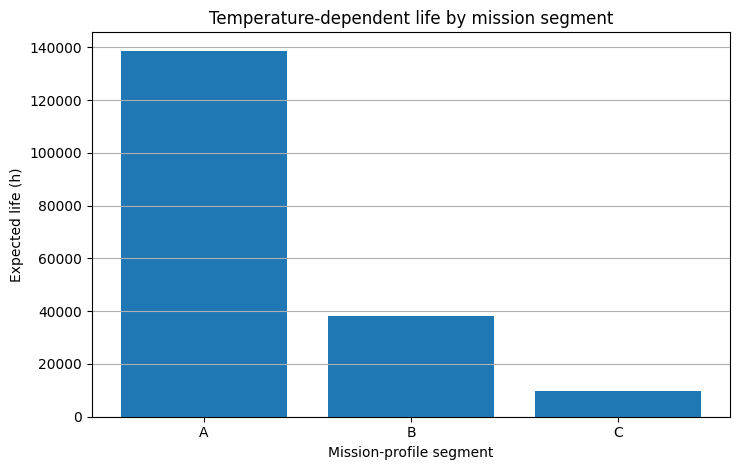

In [25]:
plt.figure(figsize=(7.5, 4.8))
plt.bar(segment_names, segment_life)
plt.xlabel("Mission-profile segment")
plt.ylabel("Expected life (h)")
plt.title("Temperature-dependent life by mission segment")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [26]:
# Subtask 8.7.10 Calculate the equivalent mission-profile lifetime using linear damage accumulation.

# The damage rate contributed by segment i is alpha_i / L_i.
segment_damage_rate = time_fraction / segment_life
total_damage_rate = np.sum(segment_damage_rate)
equivalent_life = 1.0 / total_damage_rate
 
print("Linear damage accumulation:")
for name, fraction, life, damage in zip(
    segment_names,
    time_fraction,
    segment_life,
    segment_damage_rate,
):
    print(
        f"  Segment {name}: alpha={fraction:.2f}, "
        f"life={life:,.0f} h, damage rate={damage:.6e} 1/h"
    )
 
print(f"  Total damage rate = {total_damage_rate:.6e} 1/h")
print(f"  Equivalent mission-profile life = {equivalent_life:,.0f} h")

Linear damage accumulation:
  Segment A: alpha=0.60, life=138,758 h, damage rate=4.324062e-06 1/h
  Segment B: alpha=0.30, life=38,304 h, damage rate=7.832034e-06 1/h
  Segment C: alpha=0.10, life=9,690 h, damage rate=1.032038e-05 1/h
  Total damage rate = 2.247648e-05 1/h
  Equivalent mission-profile life = 44,491 h


In [27]:
# Subtask 8.7.11 Repeat the calculation using only the weighted-average ambient temperature and weighted-average current scale.

equivalent_life = 1 / np.sum(time_fraction / segment_life)

average_ambient = np.sum(time_fraction * ambient_temperature)
average_scale = np.sum(time_fraction * current_scale)
average_loss = spectral_loss(harmonic_currents * average_scale, harmonic_esr)
average_hotspot = hotspot_temperature(average_ambient, average_loss)
average_condition_life = expected_life(average_hotspot)
life_overestimate = (average_condition_life / equivalent_life - 1) * 100


# Subtask 8.7.12 Quantify the percentage error introduced by the average-condition shortcut and explain why it occurs.

print(f"Equivalent mission-profile life = {equivalent_life:,.0f} h")
print(f"Weighted-average ambient        = {average_ambient:.2f} degC")
print(f"Weighted-average current scale  = {average_scale:.3f}")
print(f"Average-condition life          = {average_condition_life:,.0f} h")
print(f"Lifetime overestimate           = {life_overestimate:.1f} %")

Equivalent mission-profile life = 44,491 h
Weighted-average ambient        = 62.50 degC
Weighted-average current scale  = 0.850
Average-condition life          = 73,705 h
Lifetime overestimate           = 65.7 %


In [28]:
# Subtask 8.7.13 Repeat the full-load calculation at 70° ambient after all ESR values have doubled.

ambient_for_ageing = 70.0
original_loss = full_load_loss
original_hotspot = hotspot_temperature(ambient_for_ageing, original_loss)
original_life = expected_life(original_hotspot)

aged_esr = 2 * harmonic_esr
aged_loss = spectral_loss(harmonic_currents, aged_esr)
aged_hotspot = hotspot_temperature(ambient_for_ageing, aged_loss)
aged_life = expected_life(aged_hotspot)

print("Full-load comparison at 70 degC ambient:")
print(f"  Original: loss={original_loss:.3f} W, hotspot={original_hotspot:.2f} degC, life={original_life:,.0f} h")
print(f"  Aged:     loss={aged_loss:.3f} W, hotspot={aged_hotspot:.2f} degC, life={aged_life:,.0f} h")
print(f"  Life reduction = {(1-aged_life/original_life)*100:.1f} %")

Full-load comparison at 70 degC ambient:
  Original: loss=1.400 W, hotspot=77.00 degC, life=38,304 h
  Aged:     loss=2.800 W, hotspot=84.00 degC, life=23,579 h
  Life reduction = 38.4 %


**Subtask 8.7.14** Compare the original and aged losses, hot-spot temperatures, and lifetimes. Explain the feedback chain.

**Interpretation.** Frequency-dependent ESR must be applied to each current harmonic. The average-condition shortcut is optimistic because the lifetime law is nonlinear in temperature; the short, hot mission segment contributes disproportionately to accumulated damage. ESR growth creates a positive electrothermal feedback: higher ESR raises loss, hot-spot temperature, and ageing rate.